# `Polygon2d` from a smoothed Monte Carlo grain structure

A Monte Carlo Potts simulation (`upxo.ggrowth.mcgs`) gives a labelled pixel array;
Technique B (`GrainManifold2D`) tessellates and Taubin-smooths it into Shapely
polygons; `polygon_collection_from_shapely` converts that smoothed structure into a
topologically-linked `{gid: Polygon2d}` -- the same converter, same guarantee, now on
a real simulated microstructure rather than a hand-built or Voronoi-only one.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
from shapely.geometry import MultiPolygon

from upxo.ggrowth.mcgs import mcgs
import upxo.gsdataops.grid_ops as gridOps
from upxo.pxtal.geometrification import GrainManifold2D
from upxo.geoEntities.polygon2d_from_shapely import polygon_collection_from_shapely
from upxo.viz import gsviz

def _outer_ring(poly):
    # A NestedPolygon2d (a grain with an island hole) keeps its outer boundary
    # in poly.host; a plain Polygon2d has it in poly.ring.
    return poly.ring if hasattr(poly, 'ring') else poly.host.ring

def _editable(poly):
    # edit_segment and subdivide_segment are Polygon2d methods; for a
    # NestedPolygon2d the outer boundary is edited through poly.host.
    return poly if hasattr(poly, 'ring') else poly.host

def find_shared_segment(poly_a, poly_b):
    for ia, sa in enumerate(_outer_ring(poly_a).segments):
        for ib, sb in enumerate(_outer_ring(poly_b).segments):
            if sa is sb:
                return ia, ib, sa
    return None

## 1. Run the Monte Carlo simulation

Same dashboard and slice convention as `confMesh2d_compare_techniques.ipynb`.

In [2]:
_XLS = next(
    (p / "src" / "upxo" / "demos" / "confMesh" / "confMesh1.xls"
     for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "src" / "upxo" / "demos" / "confMesh" / "confMesh1.xls").is_file()),
    Path("confMesh1.xls"),
)
SLICE = 3
np.random.seed(0)

pxt = mcgs(input_dashboard=str(_XLS))
pxt.simulate()
pxt.detect_grains(library="cc3d", connectivity=4)
gstslice = pxt.gs[list(pxt.gs.keys())[SLICE]]
lgi = gstslice.lgi
print(f"slice {SLICE}: image {lgi.shape}, {len(np.unique(lgi))} grains")

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\confMesh\confMesh1.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 50.0, 1.0
     ymin, ymax, yinc: 0.0, 50.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 20
     Dimensionality: 2


Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|


GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
|--------------- MC SIM RUN COMPLETED on: ALG200---------------|
Using cc3d for grain identification
slice 3: image (51, 51), 167 grains


## 2. Geometrify and smooth (Technique B), then convert

167 smoothed grain polygons


area check: sum(cells)=2601.0000, sum(result)=2601.0000


Text(0.5, 1.0, 'Smoothed MC grain structure (slice 3) -> Polygon2d')

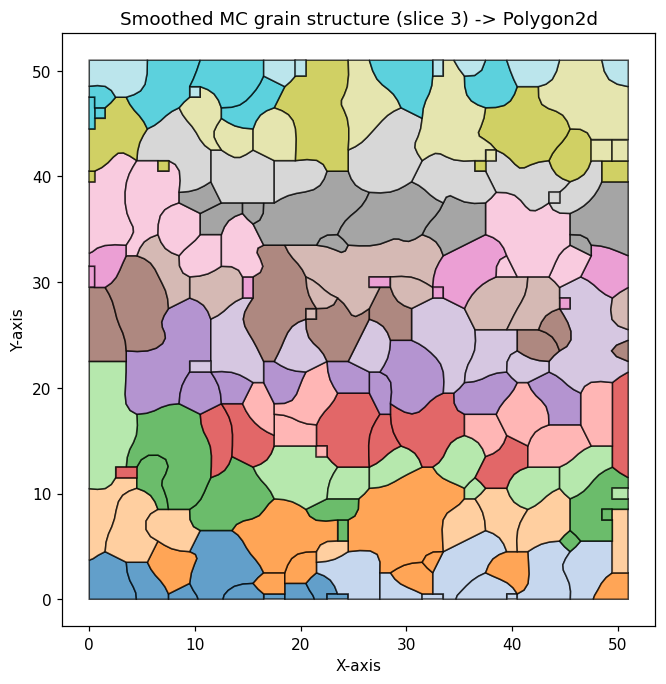

In [3]:
seeds = gridOps.generate_constrained_hybrid_seeds(
    lgi, target_spacing=1.0, bulk_spacing=1.0,
    jitter_factor=0.25, margin=0.5, padding=2.0)
manifold = GrainManifold2D.by_tessellation(lgi, seeds)
manifold.smooth_interfaces(iterations=10, lmbda=0.5, mu=-0.53)
cells = dict(manifold.cells)
print(f"{len(cells)} smoothed grain polygons")

result = polygon_collection_from_shapely(cells, verbose=False)
print(f"area check: sum(cells)={sum(c.area for c in cells.values()):.4f}, "
     f"sum(result)={sum(p.area for p in result.values()):.4f}")

fig, ax = plt.subplots(figsize=(7, 7), dpi=110)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in result.values()]), fig=fig, ax=ax)
ax.set_title(f'Smoothed MC grain structure (slice {SLICE}) -> Polygon2d')

## 3. Roughen a real interior wall

Same subdivide-then-jitter workflow as `poly2d03.ipynb`, now on a wall from a real
simulated structure. One edit, through one grain; the neighbour follows exactly, and
the domain's total area is unchanged.

roughened the wall shared by grain 1 and grain 2
total area: 2601.0000 -> 2601.0000  (conserved: True)
neighbour matches exactly, no gap: True


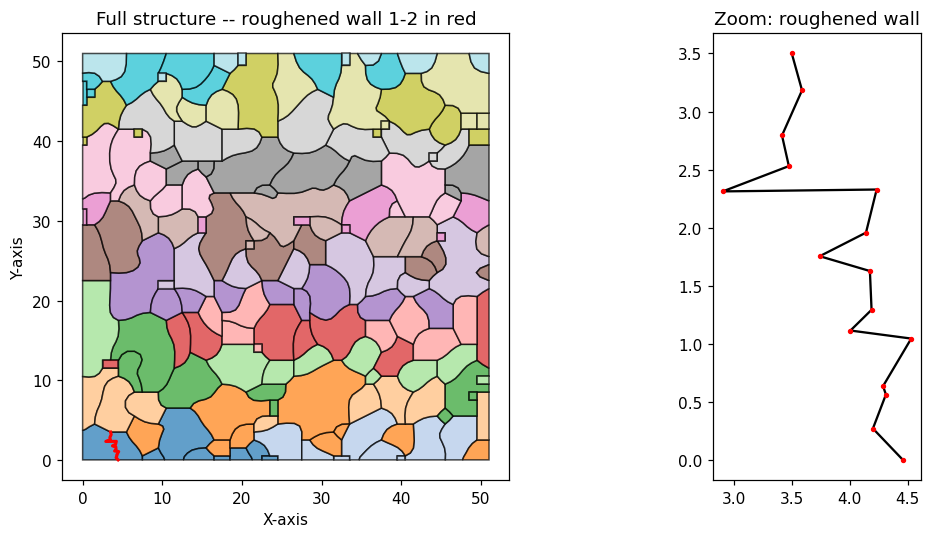

In [4]:
gids = list(result.keys())
match = None
for i, ga in enumerate(gids):
    for gb in gids[i + 1:]:
        m = find_shared_segment(result[ga], result[gb])
        if m is not None and len(m[2].get_node_coords()) >= 2:
            match = (ga, gb, *m)
            break
    if match:
        break

ga, gb, ia, ib, shared = match
pa, pb = _editable(result[ga]), _editable(result[gb])
total_before = sum(p.area for p in result.values())

rng = np.random.default_rng(seed=2)
pa.subdivide_segment(ia, n=10)
coords = pa.ring.segments[ia].get_node_coords()
tangent = coords[-1] - coords[0]
normal = np.array([-tangent[1], tangent[0]])
normal = normal / np.linalg.norm(normal)
new_coords = coords.copy()
for k in range(1, len(coords) - 1):
    new_coords[k] = new_coords[k] + rng.normal(0.0, 0.3) * normal
pa.edit_segment(ia, new_coords)

no_gap = np.array_equal(pa.ring.segments[ia].get_node_coords(), pb.ring.segments[ib].get_node_coords())
total_after = sum(p.area for p in result.values())
print(f"roughened the wall shared by grain {ga} and grain {gb}")
print(f"total area: {total_before:.4f} -> {total_after:.4f}  (conserved: {np.isclose(total_before, total_after)})")
print(f"neighbour matches exactly, no gap: {no_gap}")

wall_coords = pa.ring.segments[ia].get_node_coords()
fig, axes = plt.subplots(1, 2, figsize=(11, 5), dpi=110)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in result.values()]), fig=fig, ax=axes[0])
axes[0].plot(wall_coords[:, 0], wall_coords[:, 1], 'r-', lw=2)
axes[0].set_title(f'Full structure -- roughened wall {ga}-{gb} in red')
axes[1].plot(wall_coords[:, 0], wall_coords[:, 1], 'k-', lw=1.5)
axes[1].plot(wall_coords[:, 0], wall_coords[:, 1], 'r.', ms=5)
axes[1].set_aspect('equal')
axes[1].set_title('Zoom: roughened wall')
fig.tight_layout()

## 4. Crop to a sub-window

`smooth_interfaces` already trims every cell to the label-image domain. `trim_to_rve(bounds)`
crops to any other box. The converter takes the cropped cells as they are: cells outside the
window are empty and are dropped, and a grain cut into separate pieces keeps its largest piece
as the polygon and the rest in `props['extra_parts']`.

167 cells before the crop -> 69 grains inside the window
total area 900.0000  (window area 900.0000)


Text(0.5, 1.0, 'Cropped to window (10, 10, 40, 40)')

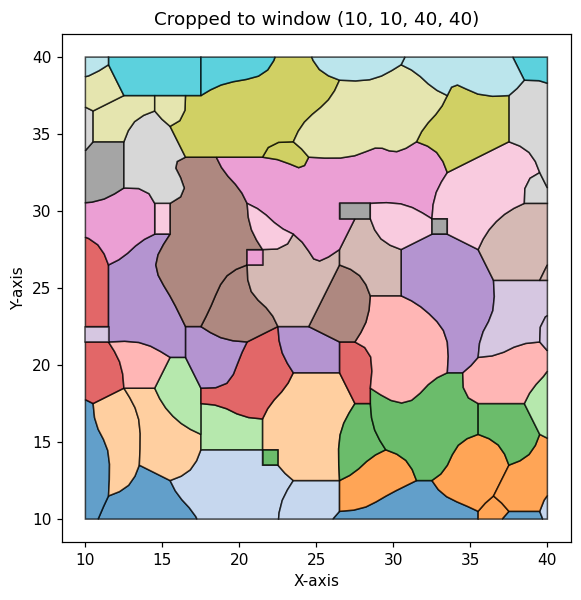

In [5]:
window = (10, 10, 40, 40)
manifold.trim_to_rve(bounds=window)
cropped = polygon_collection_from_shapely(manifold.cells)

def parts(poly):
    return [poly, *poly.props.get('extra_parts', [])]

x0, y0, x1, y1 = window
area = sum(part.area for p in cropped.values() for part in parts(p))
print(f"{len(manifold.cells)} cells before the crop -> {len(cropped)} grains inside the window")
print(f"total area {area:.4f}  (window area {(x1 - x0) * (y1 - y0):.4f})")

fig, ax = plt.subplots(figsize=(6, 6), dpi=110)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([part.make_shapely() for p in cropped.values() for part in parts(p)]),
    fig=fig, ax=ax)
ax.set_title(f'Cropped to window {window}')